# EDA sur les données brutes (Bronze) — audite Silver/Gold

Contrairement à `eda_exploration_baac.ipynb` (EDA sur Gold, déjà nettoyé/typé/joint), ce
notebook lit Bronze directement : la couche la plus proche du CSV source (cf. `gravia.bronze`,
principe de « fidélité à la source » — aucune valeur n'y est nettoyée, castée ni filtrée).

L'idée : l'EDA classique doit **informer** les décisions de nettoyage, pas seulement valider
leurs résultats après coup. Question posée ici : est-ce que ce que Silver/Gold ont décidé de
faire correspond réellement à ce que contient le brut, ou est-ce qu'on a raté quelque chose ?

**Deux vraies trouvailles ici, corrigées séparément dans le code de production (pas juste
documentées) :**

1. `lieux.nbv` contient des artefacts Excel non résolus (`#ERREUR`, `#VALEURMULTI`) — 55 lignes
   sur 273 226 (2022 : 1, 2023 : 54), jamais documentés. Avant correction, `cast_columns`
   (`strict=False`) les transformait en NULL silencieux, indiscernable d'une valeur réellement
   absente — corrigé dans `gravia.silver` pour les traiter comme la sentinelle `-1`, déjà
   utilisée pour « non renseigné » partout ailleurs sur cette colonne.
2. `grav` (usagers) : la sentinelle BAAC `-1`/`" -1"` est bien la seule anomalie rencontrée sur
   les 5 millésimes réels (avec l'unique ligne d'export vide par fichier, déjà filtrée sur
   `Num_Acc` avant d'atteindre l'agrégation) — aucun code inattendu (`"0"`, `"."` ou autre) n'a
   été trouvé. Mais `pl.col("grav").is_in([2, 3]).any()` renvoie `False` (pas `null`) si TOUS
   les usagers d'un accident ont un `grav` illisible — un cas qui n'existe pas dans les 5
   millésimes réels (vérifié plus bas), mais qui aurait silencieusement classé l'accident « non
   grave » sans lever d'erreur. Corrigé défensivement dans `gravia.gold.aggregate_usagers`
   pour les millésimes futurs.

Ce notebook vérifie aussi, sur le brut, la portée réelle du piège CLAUDE.md « les valeurs
manquantes s'écrivent de trois façons différentes selon la variable » : sur les colonnes
utilisées comme features (`ml/features/gold_features.py`), seule la sentinelle `" -1"` a été
trouvée (le `"0"` et le `"."` documentés par ailleurs concernent d'autres colonnes, hors
périmètre des features retenues — cf. résultats ci-dessous pour le détail par colonne).

Nécessite les Parquet Bronze déjà produits (`python -m gravia.bronze`).

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl

from gravia.bronze import DEFAULT_YEARS
from gravia.config import get_settings
from gravia.silver import CARACTERISTIQUES_INT_COLUMNS, LIEUX_INT_COLUMNS

In [2]:
# Exécuté avec le répertoire de travail à la racine du dépôt (comme les autres scripts de ce
# dossier, `python -m notebooks.xxx`) — nécessaire pour que `ml`/`gravia` soient importables.
OUTPUT_DIR = Path("notebooks/img")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
settings = get_settings()

#: Colonnes entières codées BAAC (caracteristiques + lieux), pour le taux de sentinelle -1 sur
#: le brut. Reprend exactement les colonnes que `gravia.silver` type comme telles — pas une
#: nouvelle liste inventée pour ce notebook.
SENTINEL_COLUMNS: tuple[tuple[str, str], ...] = tuple(
    ("caracteristiques", name) for name, _ in CARACTERISTIQUES_INT_COLUMNS
) + tuple(("lieux", name) for name, _ in LIEUX_INT_COLUMNS)


def bronze_path(table: str, year: int) -> Path:
    return settings.paths.bronze / "baac" / table / f"millesime={year}" / "part-0.parquet"

## Taux de sentinelle `-1` par colonne, calculé directement sur Bronze

À comparer à `eda_missingness.png` (calculé sur Gold, après nettoyage) : les deux devraient
converger, sans quoi une étape de nettoyage aurait introduit ou masqué un écart.

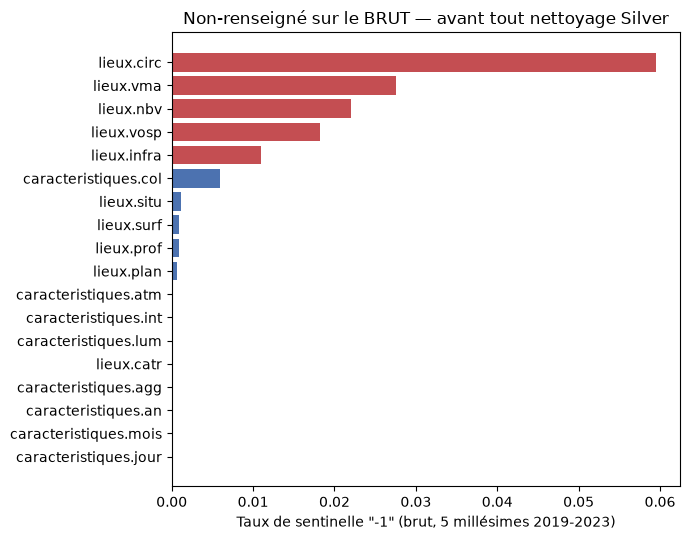

In [3]:
rates: dict[str, float] = {}
for table, column in SENTINEL_COLUMNS:
    total = 0
    sentinel = 0
    for year in DEFAULT_YEARS:
        df = pl.read_parquet(bronze_path(table, year), columns=[column])
        stripped = df[column].str.strip_chars()
        total += df.height
        sentinel += (stripped == "-1").sum()
    rates[f"{table}.{column}"] = sentinel / total

series = sorted(rates.items(), key=lambda kv: kv[1])
labels = [k for k, _ in series]
values = [v for _, v in series]

fig, ax = plt.subplots(figsize=(7, 5.5))
colors = ["#C44E52" if v >= 0.01 else "#4C72B0" for v in values]
ax.barh(labels, values, color=colors)
ax.set_xlabel('Taux de sentinelle "-1" (brut, 5 millésimes 2019-2023)')
ax.set_title("Non-renseigné sur le BRUT — avant tout nettoyage Silver")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "eda_raw_sentinel_rate.png", dpi=150)
plt.show()

`regime_circulation` (`circ`) culmine à ~5,9 %, suivi de `vma` (~2,7 %) et `nbv` (~2,2 %) —
cohérent avec ce que la couche Gold expose déjà après nettoyage (`eda_missingness.png`).

## Distribution brute de `grav` par millésime, avant agrégation en `is_grave`

Vérifie qu'aucun code inattendu (autre que 1/2/3/4/-1 et la ligne d'export vide déjà connue)
n'existe sur la colonne qui porte la cible du modèle — la seule chose qui justifierait de
revoir `aggregate_usagers` au-delà du filet de sécurité déjà posé.

Aucun code grav inattendu : seuls 1/2/3/4/-1 rencontrés sur les 5 millésimes réels.


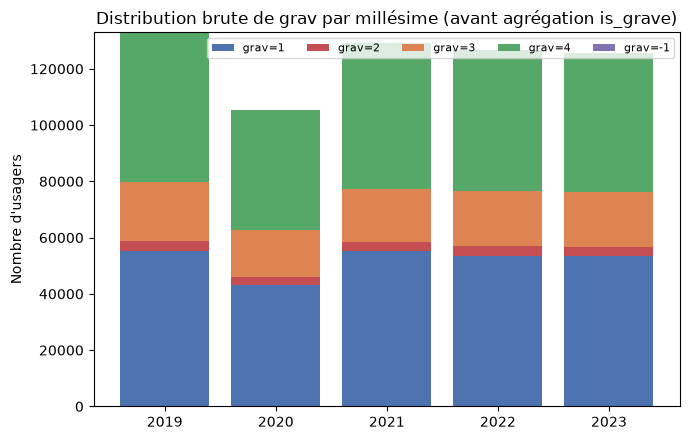

In [4]:
rows = []
for year in DEFAULT_YEARS:
    df = pl.read_parquet(bronze_path("usagers", year), columns=["Num_Acc", "grav"]).filter(
        pl.col("Num_Acc").is_not_null()  # écarte la ligne d'export vide, cf. gravia.silver
    )
    counts = df["grav"].str.strip_chars().value_counts()
    for value, count in counts.iter_rows():
        rows.append({"annee": year, "grav": value, "n": count})

wide = pl.DataFrame(rows).pivot("grav", index="annee", values="n").fill_null(0).sort("annee")
codes = [c for c in wide.columns if c != "annee"]
unexpected = [c for c in codes if c not in ("1", "2", "3", "4", "-1")]
if unexpected:
    print(f"[ATTENTION] codes grav inattendus trouvés : {unexpected}")
else:
    print("Aucun code grav inattendu : seuls 1/2/3/4/-1 rencontrés sur les 5 millésimes réels.")

fig, ax = plt.subplots(figsize=(7, 4.5))
bottom = [0] * wide.height
palette = {"1": "#4C72B0", "2": "#C44E52", "3": "#DD8452", "4": "#55A868", "-1": "#8172B2"}
years_str = [str(y) for y in wide["annee"]]
for code in sorted(codes, key=lambda c: (c == "-1", c)):
    vals = wide[code].to_list()
    ax.bar(years_str, vals, bottom=bottom, label=f"grav={code}", color=palette.get(code, "#999"))
    bottom = [b + v for b, v in zip(bottom, vals, strict=True)]
ax.set_title("Distribution brute de grav par millésime (avant agrégation is_grave)")
ax.set_ylabel("Nombre d'usagers")
ax.legend(loc="upper right", fontsize=8, ncol=5)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "eda_raw_grav_distribution.png", dpi=150)
plt.show()

La sentinelle `-1` (violet) est une part infime de chaque barre — confirmé numériquement plus
haut : aucun code inattendu, la construction de `is_grave` repose sur des données propres.